In [1]:
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import trange
import random

import torch_directml 

if torch_directml.is_available():
    device = torch_directml.device()
    print("Folosesc GPU AMD via DirectML:", torch_directml.device_name(0))
else:
    device = torch.device("cpu")
    print("DirectML nu a fost găsit. Folosesc CPU.")

Folosesc GPU AMD via DirectML: AMD RadeonT 780M 


In [2]:
class ConnectFour:
    def __init__(self):
        self.row_count = 6
        self.column_count = 7
        self.action_size = self.column_count
        self.in_a_row = 4
    def __repr__(self): return "ConnectFour"
    def get_initial_state(self): return np.zeros((self.row_count, self.column_count))
    def get_next_state(self, state, action, player):
        row = np.max(np.where(state[:, action] == 0))
        state[row, action] = player
        return state
    def get_valid_moves(self, state): return (state[0] == 0).astype(np.uint8)
    def check_win(self, state, action):
        if action == None: return False
        row = np.min(np.where(state[:, action] != 0))
        column = action
        player = state[row][column]
        def count(offset_row, offset_column):
            for i in range(1, self.in_a_row):
                r = row + offset_row * i
                c = action + offset_column * i
                if (r < 0 or r >= self.row_count or c < 0 or c >= self.column_count or state[r][c] != player):
                    return i - 1
            return self.in_a_row - 1
        return(count(1, 0) >= self.in_a_row - 1 or (count(0, 1) + count(0, -1)) >= self.in_a_row - 1 or (count(1, 1) + count(-1, -1)) >= self.in_a_row - 1 or (count(1, -1) + count(-1, 1)) >= self.in_a_row - 1)
    def get_value_and_terminated(self, state, action):
        if self.check_win(state, action): return 1, True
        if np.sum(self.get_valid_moves(state)) == 0: return 0, True
        return 0, False
    def get_opponent(self, player): return -player
    def get_opponent_value(self, value): return -value
    def change_perspective(self, state, player): return state * player
    def get_encoded_state(self, state):
        encoded_state = np.stack((state == -1, state == 0, state == 1)).astype(np.float32)
        if len(state.shape) == 3: encoded_state = np.swapaxes(encoded_state, 0, 1)
        return encoded_state

class ResBlock(nn.Module):
    def __init__(self, num_hidden):
        super().__init__()
        self.conv1 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
        self.bn1 = nn.BatchNorm2d(num_hidden)
        self.conv2 = nn.Conv2d(num_hidden, num_hidden, kernel_size = 3, padding = 1)
        self.bn2 = nn.BatchNorm2d(num_hidden)
    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        return F.relu(x)

class ResNet(nn.Module):
    def __init__(self, game, num_resBlocks, num_hidden, device):
        super().__init__()
        self.device = device
        self.startBlock = nn.Sequential(nn.Conv2d(3, num_hidden, kernel_size=3, padding=1), nn.BatchNorm2d(num_hidden), nn.ReLU())
        self.backBone = nn.ModuleList([ResBlock(num_hidden) for i in range(num_resBlocks)])
        self.policyHead = nn.Sequential(nn.Conv2d(num_hidden, 32, kernel_size=3, padding=1), nn.ReLU(), nn.Flatten(), nn.Linear(32 * game.row_count * game.column_count,  game.action_size))
        self.valueHead = nn.Sequential(nn.Conv2d(num_hidden, 3, kernel_size=3, padding=1), nn.BatchNorm2d(3), nn.ReLU(), nn.Flatten(), nn.Linear(3 * game.row_count * game.column_count, 1), nn.Tanh())
        self.to(device) # Modelul este mutat automat pe placa AMD
    def forward(self, x):
        x = self.startBlock(x)
        for resBlock in self.backBone: x = resBlock(x)
        return self.policyHead(x), self.valueHead(x)

In [3]:
class Node:
    def __init__(self, game, args, state, parent=None, action_taken=None, prior=0, visit_count=0):
        self.game = game
        self.args = args
        self.state = state
        self.parent = parent
        self.action_taken = action_taken
        self.prior = prior
        self.children = []
        self.visit_count = visit_count
        self.value_sum = 0
    def is_fully_expanded(self): return len(self.children) > 0
    def select(self):
        best_child, best_ucb = None, -np.inf
        for child in self.children:
            ucb = self.get_ucb(child)
            if ucb > best_ucb: best_child, best_ucb = child, ucb
        return best_child
    def get_ucb(self, child):
        q_value = 0 if child.visit_count == 0 else 1 - ((child.value_sum / child.visit_count) + 1) / 2
        return q_value + self.args['C'] * (math.sqrt(self.visit_count) / (child.visit_count + 1)) * child.prior
    def expand(self, policy):
        for action, prob in enumerate(policy):
            if prob > 0:
                child_state = self.game.change_perspective(self.game.get_next_state(self.state.copy(), action, 1), player=-1)
                self.children.append(Node(self.game, self.args, state=child_state, parent=self, action_taken=action, prior=prob))
    def backpropagate(self, value):
        self.value_sum += value
        self.visit_count += 1
        if self.parent is not None: self.parent.backpropagate(self.game.get_opponent_value(value))

class SPG:
    def __init__(self, game):
        self.state = game.get_initial_state()
        self.memory = []
        self.root = None
        self.node = None

class MCTSParallel:
    def __init__(self, game, args, model):
        self.game = game
        self.args = args
        self.model = model
        
    @torch.no_grad()
    def search(self, states, spGames, current_searches):
        policy, _ = self.model(torch.tensor(self.game.get_encoded_state(states), device = self.model.device))
        policy = torch.softmax(policy, axis=1).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] \
                 * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size, size=policy.shape[0])
        
        for i, spg in enumerate(spGames):
            spg_policy = policy[i] * self.game.get_valid_moves(states[i])
            spg_policy /= np.sum(spg_policy)
            spg.root = Node(self.game, self.args, states[i], visit_count = 1)
            spg.root.expand(spg_policy)

        for search in range(current_searches):
            for spg in spGames:
                spg.node = None
                node = spg.root
                while node.is_fully_expanded(): node = node.select()
                value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
                value = self.game.get_opponent_value(value)

                if is_terminal: node.backpropagate(value)
                else: spg.node = node
                    
            expandable_spGames = [mappingIdx for mappingIdx in range(len(spGames)) if spGames[mappingIdx].node is not None]

            if len(expandable_spGames) > 0:
                batch_states = np.stack([spGames[mappingIdx].node.state for mappingIdx in expandable_spGames])
                policy, value = self.model(torch.tensor(self.game.get_encoded_state(batch_states), device = self.model.device))
                policy = torch.softmax(policy, axis=1).cpu().numpy()

            for i, mappingIdx in enumerate(expandable_spGames):
                node = spGames[mappingIdx].node
                spg_policy, spg_value = policy[i], value[i].item()
                spg_policy *= self.game.get_valid_moves(node.state)
                spg_policy /= np.sum(spg_policy)
                node.expand(spg_policy)
                node.backpropagate(spg_value)

class AlphaZeroParallel:
    def __init__ (self, model, optimizer, game, args):
        self.model = model
        self.optimizer = optimizer
        self.game = game
        self.args = args
        self.mcts = MCTSParallel(game, args, model)

    def selfPlay(self):
        return_memory = []
        player = 1
        spGames = [SPG(self.game) for _ in range(self.args['num_parallel_games'])]

        while len(spGames) > 0:
            states = np.stack([spg.state for spg in spGames])
            neutral_states = self.game.change_perspective(states, player)
            
            # Randomizarea adâncimii de căutare din AlphaZero-Copy
            if np.random.random() < self.args['prob_full_search']:
                current_searches = self.args['num_searches']
            else:
                current_searches = self.args['num_searches_fast']
            
            self.mcts.search(neutral_states, spGames, current_searches)

            for i in range(len(spGames))[::-1]:
                spg = spGames[i]
                action_probs = np.zeros(self.game.action_size)
                for child in spg.root.children: action_probs[child.action_taken] = child.visit_count
                action_probs /= np.sum(action_probs)
                
                spg.memory.append((spg.root.state, action_probs, player))
                action = np.random.choice(self.game.action_size, p=action_probs)
                spg.state = self.game.get_next_state(spg.state, action, player)
                value, is_terminal = self.game.get_value_and_terminated(spg.state, action)
    
                if is_terminal:
                    for hist_neutral_state, hist_action_probs, hist_player in spg.memory:
                        hist_outcome = value if hist_player == player else self.game.get_opponent_value(value)
                        return_memory.append((self.game.get_encoded_state(hist_neutral_state), hist_action_probs, hist_outcome))
                    del spGames[i]

            player = self.game.get_opponent(player)
        return return_memory

    def train(self, memory):
        random.shuffle(memory)
        for batchIdx in range(0, len(memory), self.args['batch_size']):
            sample = memory[batchIdx:min(len(memory) - 1, batchIdx + self.args['batch_size'])]
            state, policy_targets, value_targets = zip(*sample)

            state, policy_targets, value_targets = np.array(state), np.array(policy_targets), np.array(value_targets).reshape(-1, 1)

            state = torch.tensor(state, dtype = torch.float32, device = self.model.device)
            policy_targets = torch.tensor(policy_targets, dtype = torch.float32, device = self.model.device)
            value_targets = torch.tensor(value_targets, dtype = torch.float32, device = self.model.device)

            out_policy, out_value = self.model(state)
            loss = F.cross_entropy(out_policy, policy_targets) + F.mse_loss(out_value, value_targets)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

    def learn(self):
        for iteration in range(self.args['num_iterations']):
            memory = []
            self.model.eval()
            for selfPlay_iteration in trange(self.args['num_selfPlay_iterations'] // self.args['num_parallel_games']):
                memory += self.selfPlay()

            self.model.train()
            for epoch in trange(self.args['num_epochs']): self.train(memory)
            torch.save(self.model.state_dict(), f"model_{iteration}_{self.game}.pt")
            torch.save(self.optimizer.state_dict(), f"optimizer_{iteration}_{self.game}.pt")

# MCTS Standard
class MCTS:
    def __init__(self, game, args, model):
        self.game, self.args, self.model = game, args, model
        
    @torch.no_grad()
    def search(self, state):
        root = Node(self.game, self.args, state, visit_count = 1)
        policy, _ = self.model(torch.tensor(self.game.get_encoded_state(state), device = self.model.device).unsqueeze(0))
        policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
        policy = (1 - self.args['dirichlet_epsilon']) * policy + self.args['dirichlet_epsilon'] * np.random.dirichlet([self.args['dirichlet_alpha']] * self.game.action_size)
        valid_moves = self.game.get_valid_moves(state)
        policy *= valid_moves
        policy /= np.sum(policy)
        root.expand(policy)

        for search in range(self.args['num_searches']):
            node = root
            while node.is_fully_expanded(): node = node.select()
            value, is_terminal = self.game.get_value_and_terminated(node.state, node.action_taken)
            value = self.game.get_opponent_value(value)
            
            if not is_terminal:
                policy, value = self.model(torch.tensor(self.game.get_encoded_state(node.state), device = self.model.device).unsqueeze(0))
                policy = torch.softmax(policy, axis=1).squeeze(0).cpu().numpy()
                valid_moves = self.game.get_valid_moves(node.state)
                policy *= valid_moves
                policy /= np.sum(policy)
                value = value.item()
                node.expand(policy)
          
            node.backpropagate(value)
            
        action_probs = np.zeros(self.game.action_size)
        for child in root.children: action_probs[child.action_taken] = child.visit_count
        action_probs /= np.sum(action_probs)
        return action_probs

In [4]:
game = ConnectFour()

# Inițializăm pe GPU DirectML
model = ResNet(game, 9, 128, device) 
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay = 0.0001)

args = {
    'C': 2,
    'num_searches': 60,           
    'num_searches_fast': 15,      
    'prob_full_search': 0.25,     
    'num_iterations': 3,
    'num_selfPlay_iterations': 50,
    'num_parallel_games': 10,     
    'num_epochs': 4,
    'batch_size': 64,
    'temperature': 1.25,
    'dirichlet_epsilon': 0.25,
    'dirichlet_alpha': 0.3
}

alphaZero = AlphaZeroParallel(model, optimizer, game, args)
alphaZero.learn()

  0%|                                                    | 0/4 [00:00<?, ?it/s]C:\Users\radu2\anaconda3\envs\alphazero_gpu\Lib\site-packages\torch\optim\adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)
100%|████████████████████████████████████████████| 4/4 [00:05<00:00,  1.45s/it]


Starea tablei:
[[ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  1.  0.  0.  0.]
 [ 0.  0. -1.  1. -1.  0.  0.]]

Evaluare (Value - șansa de câștig a jucătorului curent): -0.2104659080505371
Probabilități mutări (Policy): [0.08271603 0.08328073 0.2888937  0.08117528 0.2588021  0.14256026
 0.06257184]


C:\Users\radu2\AppData\Local\Temp\ipykernel_24904\618812667.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model_2_ConnectFour.pt', m

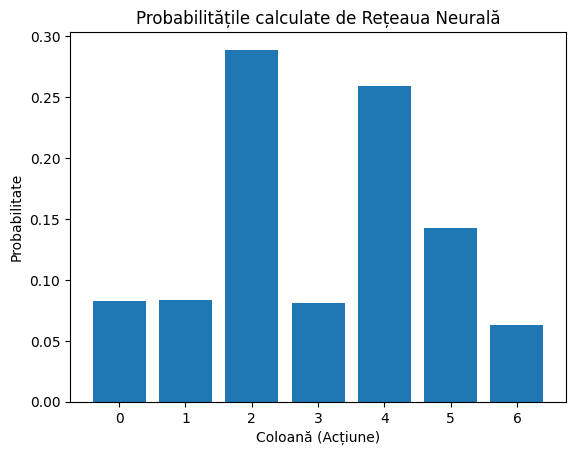

In [7]:
import matplotlib.pyplot as plt
import torch_directml

# 1. Setăm device-ul (AMD Radeon)
if torch_directml.is_available():
    device = torch_directml.device()
else:
    device = torch.device("cpu")

# 2. Inițializăm jocul ConnectFour (pe care l-ai antrenat)
game = ConnectFour()

# 3. Simulăm câteva mutări manuale pentru a crea o stare de test
state = game.get_initial_state()
state = game.get_next_state(state, 2, -1) # Mutare jucător -1 (coloana 2)
state = game.get_next_state(state, 4, -1) # Mutare jucător -1 (coloana 4)
state = game.get_next_state(state, 3, 1)  # Mutare jucător 1 (coloana 3)
state = game.get_next_state(state, 3, 1)  # Mutare jucător 1 (coloana 3)

print("Starea tablei:")
print(state)

encoded_state = game.get_encoded_state(state)

tensor_state = torch.tensor(encoded_state, device=device).unsqueeze(0)

model = ResNet(game, 9, 128, device=device)

model.load_state_dict(torch.load('model_2_ConnectFour.pt', map_location=device))
model.eval()

policy, value = model(tensor_state)
value = value.item()

policy = torch.softmax(policy, axis=1).squeeze(0).detach().cpu().numpy()

print(f"\nEvaluare (Value - șansa de câștig a jucătorului curent): {value}")
print(f"Probabilități mutări (Policy): {policy}")

# 9. Afișăm graficul cu bare (matplotlib)
plt.bar(range(game.action_size), policy)
plt.title("Probabilitățile calculate de Rețeaua Neurală")
plt.xlabel("Coloană (Acțiune)")
plt.ylabel("Probabilitate")
plt.show()